# PI Summary Figures

Implements the analysis described in `Q_C_Analysis_Workflow/data/PI_Data_Summary.xlsx`.

**Phase split**
- TRAINING = sessions with timestamp earlier than `2026-04-30T1652Z`
- TEST     = sessions on or after that timestamp

**ON / OFF trials**
- The first *N* trials of each session are *ON* (LED-on calibration). They are dropped before any rate / angle / delay metric is computed.
- *N* per session comes from the `starting ON trials` column of the PI summary spreadsheet, keyed by session timestamp.

**Trial start / end** (unchanged from `new_figures_notebook.ipynb`)
- First trial start = `Start trial logic`. Subsequent trial start = previous trial end + 1 s.
- Trial end = `Poke:` event (success / fail / miss).
- Outbound = trial start → `Target zone triggered`. Inbound = `Target zone triggered` → trial end.

**Figures (one per section)**
1. Per-session success / miss / fail rate — one panel per phase (training, test).
2. Per-session cumulative success rate across trials within session.
3. Sigmoid fit per session and pooled slope plot (training vs test).
4. Angle offset between poke and correct nosepoke.
5. Delay between zone-triggered and outcome (success / miss / fail).
6. Delay between consecutive trials.
7. Success rate over the last 40 / last 25 OFF trials per session.

## 1. Setup

Imports, repo bootstrap, and user-editable configuration. Trial-marker constants are intentionally identical to `new_figures_notebook.ipynb` so the parser produces the same trial table.

In [1]:
from pathlib import Path
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import itables
itables.init_notebook_mode()

try:
    from notebook_setup import REPO_ROOT, SRC_ROOT
except ModuleNotFoundError:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "Q_C_Analysis_Workflow").is_dir():
        REPO_ROOT = REPO_ROOT.parent
    SRC_ROOT = REPO_ROOT / "src"

for path in (REPO_ROOT, SRC_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from Q_C_Analysis_Workflow.utils import (
    build_master_trial_table,
    build_trial_table_for_directory,
    collect_session_settings_directory,
    count_events_per_session,
    display_table,
    parse_poke_outcome,
)
from data_conduit.datasources.monosource import ExperimentEvents
from Q_C_Analysis_Workflow.utils.trial_table import _events_to_long_frame

warnings.filterwarnings("ignore", category=FutureWarning)

# === User-editable config ===
data_path = "/home/callum/Keshavarzi-Lab-Workspace/data-conduit/Q_C_Analysis_Workflow/data"
PI_SUMMARY_XLSX = Path(data_path) / "PI_Data_Summary.xlsx"
base_dir = Path(data_path)

N_PORTS = 18

TRIAL_START_FOR_PARSER = "Start Trial"
FIRST_TRIAL_START_MARKER = re.compile(r"^Start trial logic$", re.IGNORECASE)
SUBSEQUENT_TRIAL_START_DELAY_S = 1.0
TRIAL_END_MARKER = re.compile(r"^Poke:")

PHASE_MARKERS = {
    "tz_available": "Target zone available",
    "tz_triggered": "Target zone triggered",
    "await_poke":   "Await poke",
}
SEGMENTS = {
    "outbound": ("start", "tz_triggered"),
    "inbound":  ("tz_triggered", "end"),
}

# Sessions whose timestamp sorts strictly before this string are TRAINING; rest are TEST.
# Padded to full timestamp width so lex compare works correctly against e.g. '2026-04-30T165228Z'.
PHASE_CUTOFF = "2026-04-30T165200Z"

SAVE_FIGURES = False
figure_dir = REPO_ROOT / "Q_C_Analysis_Workflow" / "design_space" / "figures"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Load Sessions and Build Trial Table

Walk the data tree, parse behavioural trials with the lab markers, then overwrite trial start times with the lab convention (`Start trial logic` for trial 1, `prev_end + 1 s` for the rest). Multi-CSV sessions are handled by `_events_to_long_frame`, which concatenates all CSVs in a session's `ExperimentEvents/` folder into a single time-sorted frame.

In [2]:
collected = collect_session_settings_directory(base_dir=base_dir, verbose=False)
sessions_df = collected["sessions"].copy()
bonsai_trials_df = collected["trials"].copy()

if sessions_df.empty:
    raise ValueError(f"No valid SessionSettings files were found under {base_dir}")

behavioural_trials = build_trial_table_for_directory(
    base_dir=base_dir,
    sessions_df=sessions_df,
    start=TRIAL_START_FOR_PARSER,
    end=TRIAL_END_MARKER,
    phases=PHASE_MARKERS,
    segments=SEGMENTS,
    outcome_parser=parse_poke_outcome,
)

if behavioural_trials.empty:
    raise ValueError("No behavioural trials parsed; check event markers and event-folder layout.")


def _first_event_time_by_session(base_dir, sessions, marker, event_column="Event"):
    """Return {USID: first matching ExperimentEvents time} per session."""
    first_times = {}
    for row in sessions.itertuples(index=False):
        session_path = base_dir / row.mouse / row.day / row.session
        try:
            events_obj = ExperimentEvents(experiment_directory_path=str(session_path), verbose=False).df
            events_df = _events_to_long_frame(events_obj, event_column)
        except Exception:
            continue
        if events_df.empty or event_column not in events_df.columns:
            continue
        mask = events_df[event_column].astype(str).str.contains(marker, regex=True, na=False)
        if mask.any():
            first_times[row.USID] = events_df.index[mask][0]
    return first_times


def _apply_lab_trial_start_rule(trials, sessions, base_dir):
    """First trial -> 'Start trial logic' time; subsequent -> previous_end + 1 s.

    Outbound and inbound durations are recomputed against the new start_time
    so they reflect the behavioural definition, not the parser's Bonsai-event
    bracketing.
    """
    adjusted = trials.sort_values(["USID", "trial_index"]).copy()
    adjusted["logged_start_time"] = adjusted["start_time"]

    first_starts = _first_event_time_by_session(
        base_dir=base_dir, sessions=sessions, marker=FIRST_TRIAL_START_MARKER,
    )

    previous_end = adjusted.groupby("USID")["end_time"].shift(1)
    adjusted["start_time"] = previous_end + SUBSEQUENT_TRIAL_START_DELAY_S

    is_first = adjusted.groupby("USID").cumcount() == 0
    first_from_events = adjusted.loc[is_first, "USID"].map(first_starts)
    adjusted.loc[is_first, "start_time"] = first_from_events.fillna(
        adjusted.loc[is_first, "logged_start_time"]
    )

    adjusted["outbound_duration"] = adjusted["tz_triggered_time"] - adjusted["start_time"]
    adjusted["inbound_duration"]  = adjusted["end_time"]          - adjusted["tz_triggered_time"]
    return adjusted


behavioural_trials = _apply_lab_trial_start_rule(
    trials=behavioural_trials, sessions=sessions_df, base_dir=base_dir,
)

master_trials = build_master_trial_table(
    behavioural_trials=behavioural_trials, bonsai_trials=bonsai_trials_df,
)

print(f"sessions discovered : {len(sessions_df):,}")
print(f"behavioural trials  : {len(behavioural_trials):,}")
print(f"master_trials rows  : {len(master_trials):,}")

ValueError: No valid SessionSettings files were found under /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Q_C_Analysis_Workflow/data

## 3. Parser-vs-Events QC

`n_trials_parser` should equal `n_trials_events` (raw `Poke:` count from the events log) for every session. If they disagree, the parser is dropping or duplicating trials — most likely cause is an unmatched `Start Trial` near a session boundary or a multi-CSV session where one file was missed. `n_trials` (Bonsai-configured) can legitimately exceed the parser count: planned-but-unfired trials live in SessionSettings.

In [ ]:
events_per_session = count_events_per_session(
    base_dir=base_dir, sessions_df=sessions_df, marker=TRIAL_END_MARKER,
)
parser_per_session = behavioural_trials.groupby("USID").size().rename("n_trials_parser")

trial_count_check = (
    sessions_df[["USID", "mouse", "day", "session", "n_trials"]]
    .merge(parser_per_session.reset_index(), on="USID", how="left")
    .merge(events_per_session.rename("n_trials_events").reset_index(), on="USID", how="left")
    .fillna({"n_trials_parser": 0, "n_trials_events": 0})
    .astype({"n_trials_parser": int, "n_trials_events": int})
    .assign(parser_matches_events=lambda d: d["n_trials_parser"] == d["n_trials_events"])
)

print(f"parser==events agree in {trial_count_check['parser_matches_events'].sum()} / {len(trial_count_check)} sessions")
display_table(trial_count_check)

parser==events agree in 32 / 32 sessions


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


## 4. Parse PI Summary Spreadsheet — `starting ON trials` per session

The spreadsheet has a `File / starting ON trials / nb of trials OFF` triple repeated across columns, plus a few `combine ...` columns where one ON count covers several sessions. We only consume the simple triples here; combined columns are skipped because their ON count can't be uniquely attributed to one session. The authoritative per-session ON count is derived from the events log in the next cell — this cell exists so we can compare what the PI wrote in the spreadsheet against what the events actually say.

In [ ]:
def parse_pi_summary_on_counts(xlsx_path):
    """Return {session_timestamp: starting_on_trials} from the PI spreadsheet.

    Only the simple ``File / starting ON trials / nb of trials OFF`` triples
    in row index 3 are consumed. ``combine ...`` columns are skipped because
    their ON count aggregates several sessions.
    """
    raw = pd.read_excel(xlsx_path, header=None)
    headers = raw.iloc[3].astype(str).str.strip().tolist()

    file_cols = [i for i, h in enumerate(headers) if h.lower() == "file"]
    on_counts = {}

    for col in file_cols:
        on_col = col + 1
        if on_col >= raw.shape[1]:
            continue
        for row_idx in range(4, raw.shape[0]):
            session_value = raw.iat[row_idx, col]
            on_value = raw.iat[row_idx, on_col]
            if pd.isna(session_value) or pd.isna(on_value):
                continue
            session_id = str(session_value).strip()
            if not session_id.endswith("Z"):
                continue
            try:
                on_counts[session_id] = int(on_value)
            except (TypeError, ValueError):
                continue
    return on_counts


on_counts_xlsx = parse_pi_summary_on_counts(PI_SUMMARY_XLSX)

xlsx_set = set(on_counts_xlsx)
disk_set = set(sessions_df["session"])

print(f"sessions in xlsx (non-combined File cols): {len(xlsx_set)}")
print(f"sessions on disk                        : {len(disk_set)}")
print(f"on disk AND in xlsx                     : {len(disk_set & xlsx_set)}")
print()

print("--- on disk but NOT in xlsx (missing from spreadsheet) ---")
missing_from_xlsx = sessions_df[~sessions_df["session"].isin(xlsx_set)]
display_table(missing_from_xlsx[["USID", "mouse", "day", "session"]])

print("--- in xlsx but NOT on disk (data not yet copied / combined-column timestamps) ---")
missing_from_disk = sorted(xlsx_set - disk_set)
print(missing_from_disk)

sessions in xlsx (non-combined File cols): 20
sessions on disk                        : 32
on disk AND in xlsx                     : 12

--- on disk but NOT in xlsx (missing from spreadsheet) ---


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


--- in xlsx but NOT on disk (data not yet copied / combined-column timestamps) ---
['2026-04-21T155201Z', '2026-04-23T160907Z', '2026-04-23T165237Z', '2026-04-25T182521Z', '2026-04-25T190915Z', '2026-04-28T124547Z', '2026-04-28T165257Z', '2026-04-29T161826Z']


## 5. Authoritative ON Count from the Events Log

Per session, derive the number of starting ON trials directly from `ExperimentEvents`:

1. `t_led_off` = time of the last `NosePokesLED ON` event.
2. `t_min_size` = first time the target-zone radius reaches its session-specific minimum (taken as the smallest `Radius : N` value seen in `Target zone available (...)` events for that session).
3. The first OFF trial is the first parsed trial whose `start_time` is later than `max(t_led_off, t_min_size)`. ON count = `(first_off_trial_index - 1)`.

This is more conservative than counting LED-ON events alone: if the target zone keeps shrinking after the LED is turned off, those trials still count as ON. The xlsx ON counts are loaded for comparison only.

In [ ]:
LED_ON_PATTERN = re.compile(r"^NosePokesLED ON$")
TZ_AVAILABLE_PATTERN = re.compile(r"^Target zone available")
RADIUS_PATTERN = re.compile(r"Radius\s*:\s*(\d+)")


def derive_on_count_from_events(base_dir, session_row, behavioural_trials):
    session_path = base_dir / session_row["mouse"] / session_row["day"] / session_row["session"]
    record = {
        "USID": session_row["USID"],
        "n_led_on_events": 0,
        "min_target_zone_radius": np.nan,
        "t_led_off": np.nan,
        "t_min_size": np.nan,
        "on_count_events": np.nan,
        "on_count_led_only": np.nan,
    }
    if not session_path.is_dir():
        return record

    try:
        events_obj = ExperimentEvents(experiment_directory_path=str(session_path), verbose=False).df
    except Exception:
        return record

    events_df = _events_to_long_frame(events_obj, "Event")
    if events_df.empty or "Event" not in events_df.columns:
        return record

    events = events_df["Event"].astype(str)

    led_mask = events.str.match(LED_ON_PATTERN)
    record["n_led_on_events"] = int(led_mask.sum())
    if led_mask.any():
        record["t_led_off"] = float(events_df.index[led_mask][-1])

    tz_mask = events.str.match(TZ_AVAILABLE_PATTERN)
    if tz_mask.any():
        radii = events[tz_mask].str.extract(RADIUS_PATTERN, expand=False).astype(float).dropna()
        if not radii.empty:
            min_r = float(radii.min())
            record["min_target_zone_radius"] = min_r
            record["t_min_size"] = float(radii.index[radii == min_r][0])

    candidates = [v for v in (record["t_led_off"], record["t_min_size"]) if pd.notna(v)]
    if candidates:
        threshold = max(candidates)
        session_trials = behavioural_trials[behavioural_trials["USID"] == session_row["USID"]]
        if not session_trials.empty:
            after = session_trials.loc[session_trials["start_time"] > threshold]
            record["on_count_events"] = (
                int(after.iloc[0]["trial_index"]) - 1 if not after.empty else int(len(session_trials))
            )

    record["on_count_led_only"] = record["n_led_on_events"]
    return record


on_records = [
    derive_on_count_from_events(base_dir, row, behavioural_trials)
    for _, row in sessions_df.iterrows()
]
on_counts_events_df = pd.DataFrame(on_records)

on_count_compare = (
    sessions_df[["USID", "mouse", "day", "session", "n_trials"]]
    .merge(on_counts_events_df, on="USID", how="left")
    .assign(starting_on_trials_xlsx=lambda d: d["session"].map(on_counts_xlsx))
)
on_count_compare["xlsx_matches_events"] = (
    on_count_compare["starting_on_trials_xlsx"] == on_count_compare["on_count_events"]
)

# Authoritative ON count = events-log derivation; LED-only is a defensive fallback.
on_count_compare["starting_on_trials"] = (
    on_count_compare["on_count_events"]
    .fillna(on_count_compare["on_count_led_only"])
    .astype("Int64")
)

sessions_df = sessions_df.merge(
    on_count_compare[["USID", "starting_on_trials"]],
    on="USID",
    how="left",
)

n_xlsx = int(on_count_compare["starting_on_trials_xlsx"].notna().sum())
n_match = int((on_count_compare["xlsx_matches_events"] & on_count_compare["starting_on_trials_xlsx"].notna()).sum())
print(f"sessions with xlsx ON count : {n_xlsx}")
print(f"xlsx == events-derived      : {n_match} / {n_xlsx}")
print(f"events-derived NaN          : {on_count_compare['on_count_events'].isna().sum()}")
print()

display_table(
    on_count_compare[[
        "USID", "mouse", "day", "session", "n_trials",
        "n_led_on_events", "min_target_zone_radius",
        "on_count_events", "starting_on_trials_xlsx",
        "xlsx_matches_events", "starting_on_trials",
    ]]
)

sessions with xlsx ON count : 12
xlsx == events-derived      : 12 / 12
events-derived NaN          : 0



Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


## 6. Phase Split + ON-Trial Filter

Tag every session as `training` (timestamp earlier than `PHASE_CUTOFF`) or `test`, then drop the first `starting_on_trials` rows of each session — the LED-on calibration trials that the PI excludes from analysis. The result, `analysis_trials`, has one row per OFF trial with a fresh `off_trial_index` (1-based, within the OFF phase) and pre-computed boolean outcome flags.

In [ ]:
sessions_df["phase"] = np.where(
    sessions_df["session"].astype(str) < PHASE_CUTOFF, "training", "test",
)

session_meta = sessions_df[["USID", "phase", "starting_on_trials"]].copy()
session_meta["starting_on_trials"] = session_meta["starting_on_trials"].fillna(0).astype(int)

analysis_trials = behavioural_trials.merge(session_meta, on="USID", how="left")
analysis_trials = analysis_trials[
    analysis_trials["trial_index"] > analysis_trials["starting_on_trials"]
].copy()
analysis_trials["off_trial_index"] = (
    analysis_trials["trial_index"] - analysis_trials["starting_on_trials"]
)

analysis_trials["outcome"]    = analysis_trials["outcome"].astype(str)
analysis_trials["is_success"] = analysis_trials["outcome"] == "success"
analysis_trials["is_miss"]    = analysis_trials["outcome"] == "miss"
analysis_trials["is_fail"]    = analysis_trials["outcome"] == "fail"

phase_summary = (
    analysis_trials
    .groupby("phase", as_index=False)
    .agg(
        n_sessions=("USID", "nunique"),
        n_animals=("mouse", "nunique"),
        n_off_trials=("UTID", "size"),
    )
)
print("=== Phase split + ON-trial filter ===")
print(phase_summary.to_string(index=False))
print()
display_table(
    analysis_trials.head(30)[[
        "UTID", "mouse", "day", "session", "phase",
        "trial_index", "starting_on_trials", "off_trial_index",
        "outcome", "is_success",
    ]]
)

=== Phase split + ON-trial filter ===
phase  n_sessions  n_animals  n_off_trials
 test          31          2          1446



Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


## 7. Figure 1 — Success / Miss / Fail Rate per Session

Two panels (training, test). Sessions ordered strictly chronologically along the x-axis. Six lines per panel: each `(mouse, metric)` combination — mouse → colour, metric → linestyle + marker (success solid `o`, miss dashed `s`, fail dotted `x`). Each line has gaps where the other animal was running.

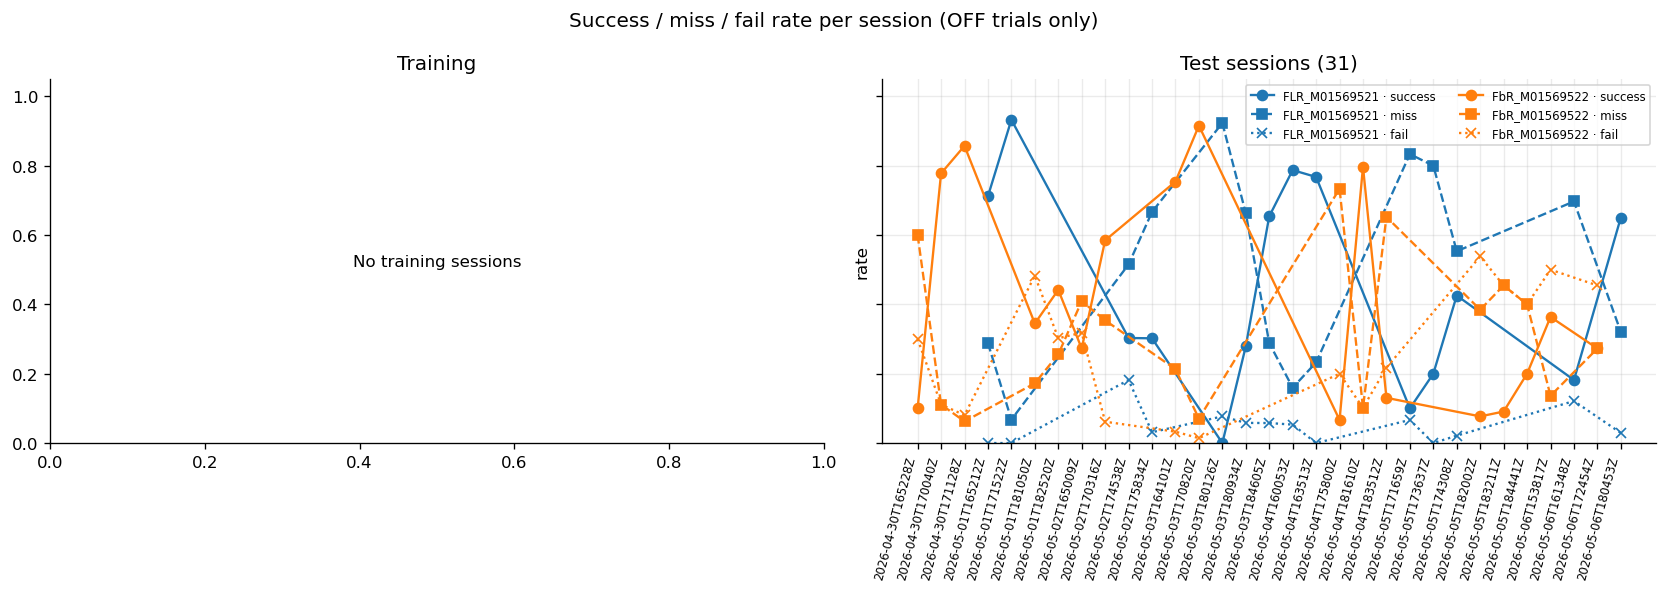

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
session_keys = ["mouse", "day", "session", "USID", "phase"]
rates_per_session = (
    analysis_trials
    .groupby(session_keys, as_index=False)
    .agg(
        success_rate=("is_success", "mean"),
        miss_rate=("is_miss", "mean"),
        fail_rate=("is_fail", "mean"),
        n_trials=("UTID", "size"),
    )
)


def plot_phase_rates(ax, rates, *, phase):
    sub = rates.loc[rates["phase"] == phase].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No {phase} sessions", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(phase.title())
        return

    sub = sub.sort_values("session").reset_index(drop=True)
    sub["x"] = np.arange(len(sub))

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    metric_styles = [
        ("success_rate", "success", "-",  "o"),
        ("miss_rate",    "miss",    "--", "s"),
        ("fail_rate",    "fail",    ":",  "x"),
    ]

    for mouse, m_sub in sub.groupby("mouse"):
        colour = mouse_colour[mouse]
        for col, label, ls, marker in metric_styles:
            ax.plot(
                m_sub["x"], m_sub[col],
                color=colour, linestyle=ls, marker=marker,
                linewidth=1.4, markersize=6,
                label=f"{mouse} · {label}",
            )

    ax.set_xticks(sub["x"])
    ax.set_xticklabels(sub["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("rate")
    ax.set_title(f"{phase.title()} sessions ({len(sub)})")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, loc="upper right", ncol=2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_phase_rates(axes[0], rates_per_session, phase="training")
plot_phase_rates(axes[1], rates_per_session, phase="test")
fig.suptitle("Success / miss / fail rate per session (OFF trials only)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "01_rates_per_session.png", bbox_inches="tight", dpi=300)
plt.show()

display_table(rates_per_session)

## 8. Figure 2 — Cumulative Success Rate Within Session

Per session, the running success rate over OFF trials. One thin line per session (coloured by mouse), with a heavier mean line per mouse on top. Two panels (training, test).

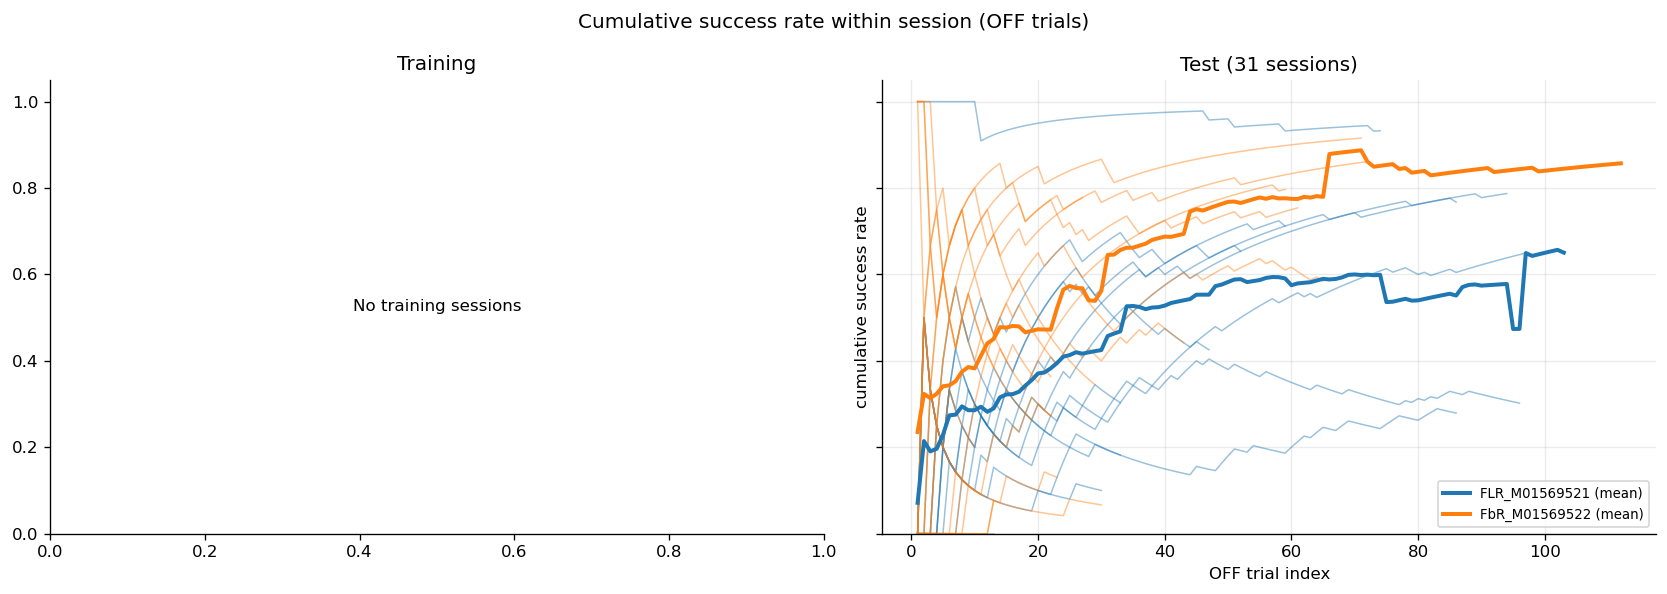

In [ ]:
analysis_trials = analysis_trials.sort_values(["USID", "off_trial_index"]).copy()
analysis_trials["cumulative_success_rate"] = (
    analysis_trials.groupby("USID")["is_success"].cumsum()
    / analysis_trials.groupby("USID").cumcount().add(1)
)


def plot_cumulative(ax, trials, *, phase):
    sub = trials.loc[trials["phase"] == phase]
    if sub.empty:
        ax.text(0.5, 0.5, f"No {phase} sessions", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(phase.title())
        return

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for _, session in sub.groupby("USID"):
        colour = mouse_colour[session["mouse"].iloc[0]]
        ax.plot(
            session["off_trial_index"],
            session["cumulative_success_rate"],
            color=colour, linewidth=0.9, alpha=0.45,
        )

    # Mean curve per mouse (averaged at each OFF trial index across that mouse's sessions).
    for mouse in mice:
        mouse_trials = sub.loc[sub["mouse"] == mouse]
        per_x = (
            mouse_trials
            .groupby("off_trial_index")["cumulative_success_rate"]
            .mean()
            .sort_index()
        )
        ax.plot(
            per_x.index, per_x.values,
            color=mouse_colour[mouse], linewidth=2.4, alpha=1.0,
            label=f"{mouse} (mean)",
        )

    ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("OFF trial index")
    ax.set_ylabel("cumulative success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{phase.title()} ({sub['USID'].nunique()} sessions)")
    ax.grid(True, alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_cumulative(axes[0], analysis_trials, phase="training")
plot_cumulative(axes[1], analysis_trials, phase="test")
fig.suptitle("Cumulative success rate within session (OFF trials)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "02_cumulative_success.png", bbox_inches="tight", dpi=300)
plt.show()

## 9. Figure 3 — Sigmoid Fit per Session and Pooled Slopes

Per session, fit a 4-parameter logistic `L / (1 + exp(-k (x - x0))) + b` to the within-session cumulative success rate (`x = off_trial_index`). The slope at the inflection point is `L·k/4` — a single learning-speed scalar. Two panels (training, test) plot one slope per session, one line per mouse, x ordered chronologically. A QC panel below overlays the fit against raw cumulative success for the most recent training session.

sessions fit successfully : 30 / 31


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


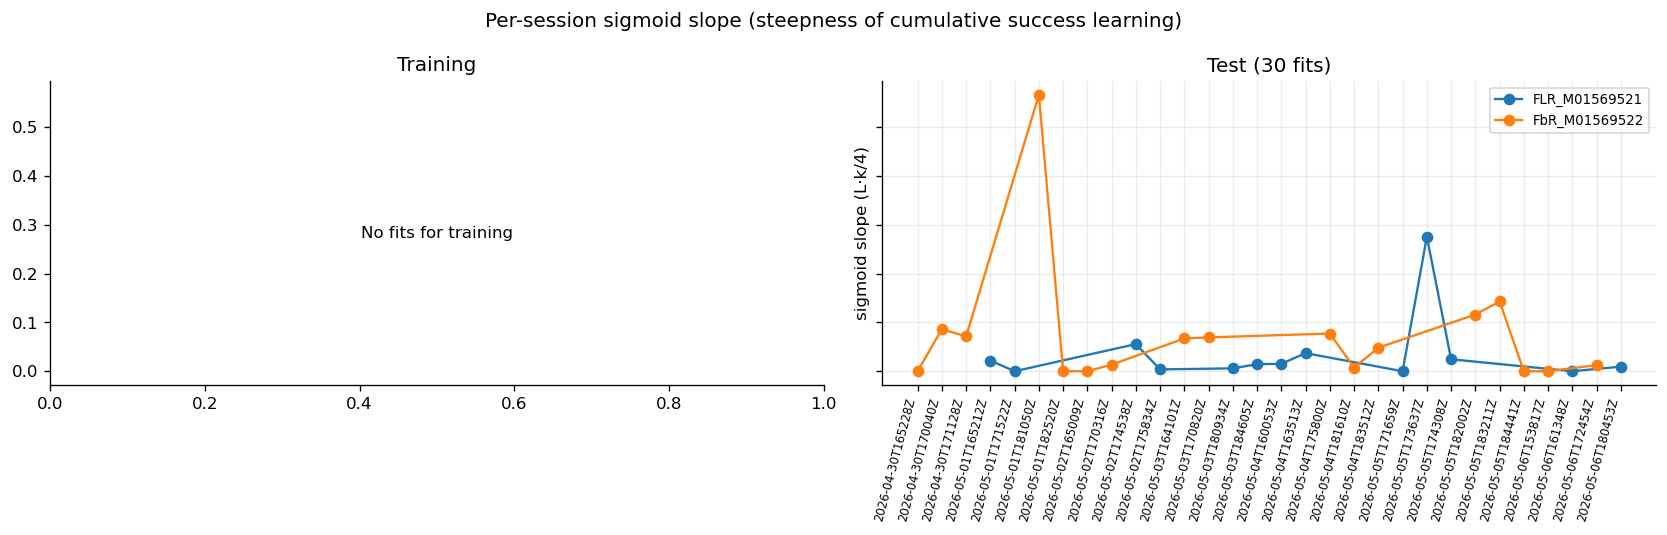

In [ ]:
def _logistic(x, L, k, x0, b):
    return L / (1.0 + np.exp(-k * (x - x0))) + b


def fit_sigmoid_per_session(trials, *, y_column="cumulative_success_rate", x_column="off_trial_index"):
    rows = []
    for usid, sub in trials.groupby("USID"):
        sub = sub.sort_values(x_column)
        x = sub[x_column].to_numpy(dtype=float)
        y = sub[y_column].to_numpy(dtype=float)
        record = {
            "USID":   usid,
            "mouse":   sub["mouse"].iloc[0],
            "phase":   sub["phase"].iloc[0],
            "session": sub["session"].iloc[0],
            "n_off_trials": int(len(sub)),
        }
        if len(sub) < 6 or np.allclose(y, y[0]):
            record.update({"L": np.nan, "k": np.nan, "x0": np.nan, "b": np.nan, "slope": np.nan})
            rows.append(record)
            continue
        try:
            p0 = (max(y[-1] - y[0], 1e-3), 0.05, np.median(x), y[0])
            bounds = ([0.0, 0.0, x.min() - 1, 0.0], [1.0, 5.0, x.max() + 1, 1.0])
            popt, _ = curve_fit(_logistic, x, y, p0=p0, bounds=bounds, maxfev=10_000)
            L, k, x0, b = popt
            record.update({"L": L, "k": k, "x0": x0, "b": b, "slope": L * k / 4.0})
        except Exception:
            record.update({"L": np.nan, "k": np.nan, "x0": np.nan, "b": np.nan, "slope": np.nan})
        rows.append(record)
    return pd.DataFrame(rows)


sigmoid_fits = fit_sigmoid_per_session(analysis_trials)
print(f"sessions fit successfully : {sigmoid_fits['slope'].notna().sum()} / {len(sigmoid_fits)}")
display_table(sigmoid_fits)


def _plot_sigmoid_slopes(ax, fits, *, phase):
    sub = fits.loc[(fits["phase"] == phase) & fits["slope"].notna()]
    if sub.empty:
        ax.text(0.5, 0.5, f"No fits for {phase}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(phase.title())
        return
    sub = sub.sort_values("session").reset_index(drop=True)
    sub["x"] = np.arange(len(sub))

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for mouse, m_sub in sub.groupby("mouse"):
        ax.plot(
            m_sub["x"], m_sub["slope"],
            color=mouse_colour[mouse], marker="o", linewidth=1.4, label=mouse,
        )

    ax.set_xticks(sub["x"])
    ax.set_xticklabels(sub["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylabel("sigmoid slope (L·k/4)")
    ax.set_title(f"{phase.title()} ({len(sub)} fits)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
_plot_sigmoid_slopes(axes[0], sigmoid_fits, phase="training")
_plot_sigmoid_slopes(axes[1], sigmoid_fits, phase="test")
fig.suptitle("Per-session sigmoid slope (steepness of cumulative success learning)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "03_sigmoid_slopes.png", bbox_inches="tight", dpi=300)
plt.show()


qa_target = (
    sigmoid_fits[sigmoid_fits["phase"] == "training"]
    .dropna(subset=["slope"])
    .sort_values("session")
    .tail(1)
)
if not qa_target.empty:
    qa_usid = qa_target.iloc[0]["USID"]
    qa_trials = analysis_trials[analysis_trials["USID"] == qa_usid].sort_values("off_trial_index")
    qa_fit = qa_target.iloc[0]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(qa_trials["off_trial_index"], qa_trials["cumulative_success_rate"],
            color="black", linewidth=1.2, label="cumulative success (data)")
    xs = np.linspace(qa_trials["off_trial_index"].min(), qa_trials["off_trial_index"].max(), 200)
    ys = _logistic(xs, qa_fit["L"], qa_fit["k"], qa_fit["x0"], qa_fit["b"])
    ax.plot(xs, ys, color="C3", linewidth=2.0, label=f"fit (slope={qa_fit['slope']:.4f})")
    ax.set_xlabel("OFF trial index")
    ax.set_ylabel("cumulative success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"QC: sigmoid fit overlay — {qa_usid}")
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

## 10. Figure 4 — Angle Offset Between Poke and Correct Nosepoke

`parse_poke_outcome` already extracted `chosen_port` and `correct_port` from each `Poke:` event. Convert the port-index difference to degrees using `360 / N_PORTS`, then plot per-session means in a 2×2 grid: top row = mean `|error angle|`, bottom row = mean signed error angle. Misses (`chosen_port < 0`) are excluded.

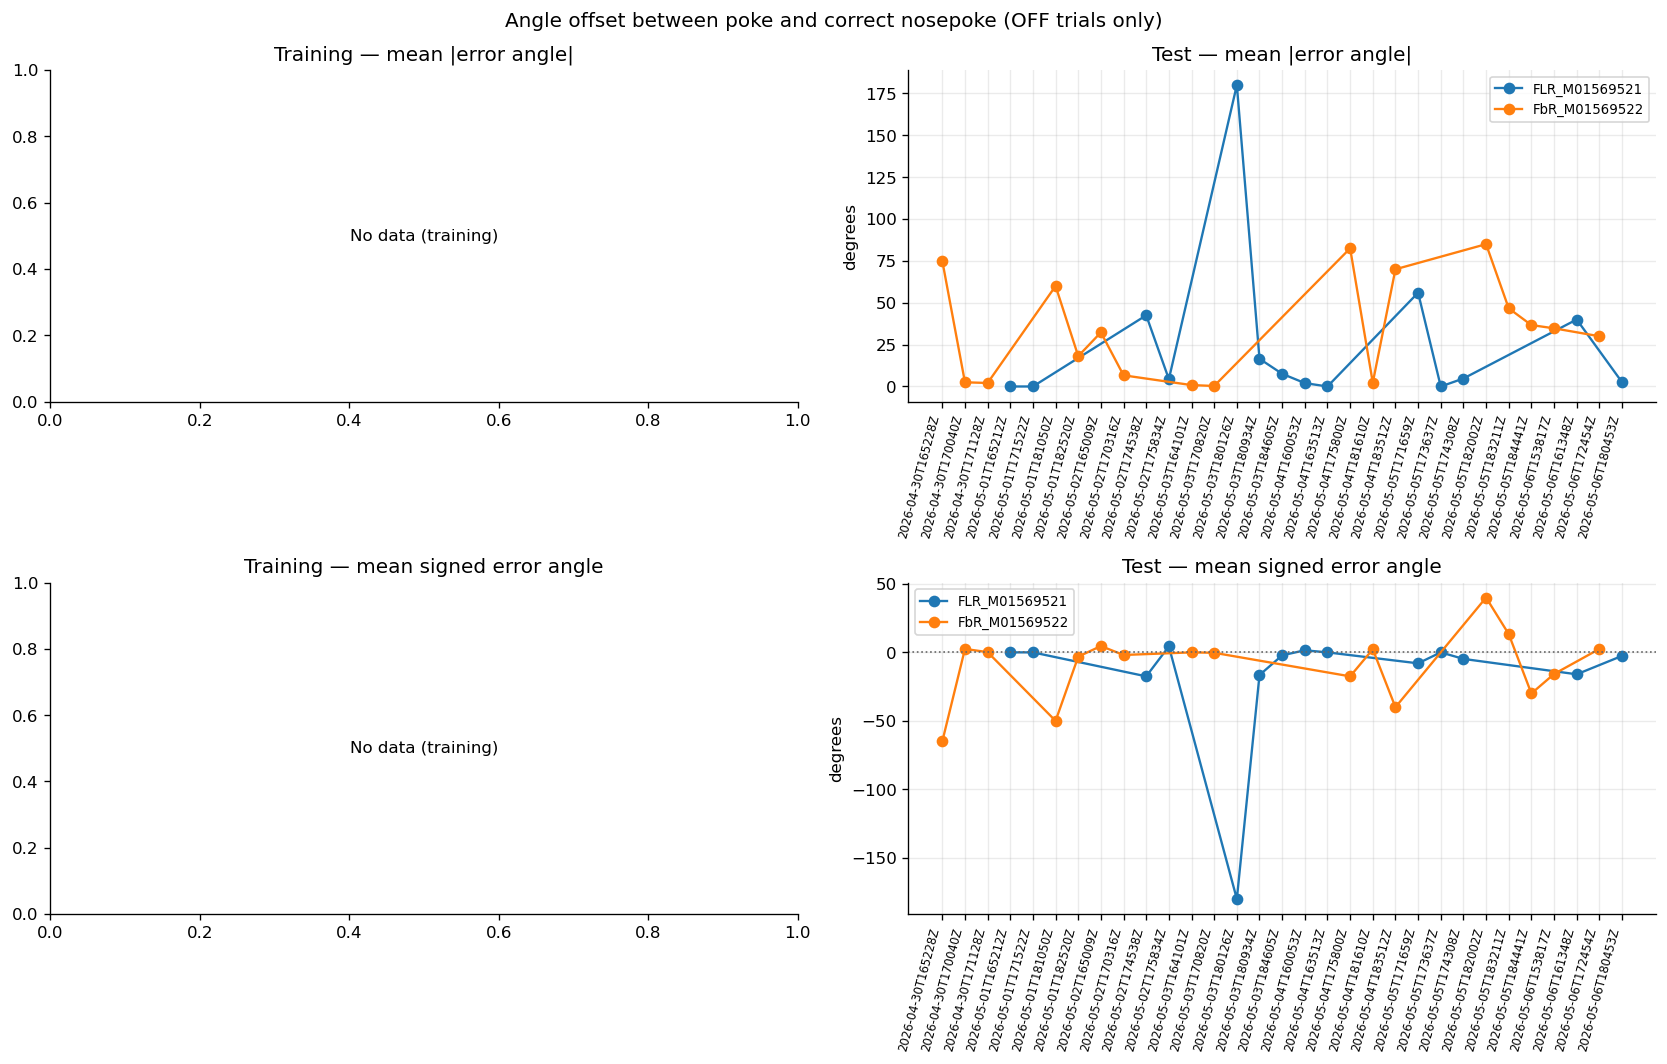

In [ ]:
port_cols = behavioural_trials[["UTID", "chosen_port", "correct_port"]]
analysis_trials = analysis_trials.drop(
    columns=[c for c in ("chosen_port", "correct_port") if c in analysis_trials.columns]
).merge(port_cols, on="UTID", how="left")

half_n = N_PORTS // 2
chosen = pd.to_numeric(analysis_trials["chosen_port"], errors="coerce")
correct = pd.to_numeric(analysis_trials["correct_port"], errors="coerce")

signed_offset_idx = ((chosen - correct + half_n) % N_PORTS) - half_n
analysis_trials["signed_error_angle"] = np.where(
    chosen >= 0, signed_offset_idx * (360.0 / N_PORTS), np.nan,
)
analysis_trials["absolute_error_angle"] = analysis_trials["signed_error_angle"].abs()


def plot_angle(ax, trials, *, phase, column, title, ylabel, hline=None):
    sub = trials.loc[(trials["phase"] == phase) & trials[column].notna()]
    if sub.empty:
        ax.text(0.5, 0.5, f"No data ({phase})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    per_session = (
        sub.groupby(["mouse", "session", "USID"], as_index=False)
           .agg(value=(column, "mean"), n=(column, "size"))
           .sort_values("session")
           .reset_index(drop=True)
    )
    per_session["x"] = np.arange(len(per_session))

    cmap = plt.get_cmap("tab10")
    mice = sorted(per_session["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for mouse, m_sub in per_session.groupby("mouse"):
        ax.plot(
            m_sub["x"], m_sub["value"],
            color=mouse_colour[mouse], marker="o", linewidth=1.4, label=mouse,
        )

    if hline is not None:
        ax.axhline(hline, color="0.4", linewidth=1, linestyle=":")

    ax.set_xticks(per_session["x"])
    ax.set_xticklabels(per_session["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_angle(axes[0, 0], analysis_trials, phase="training",
           column="absolute_error_angle",
           title="Training — mean |error angle|", ylabel="degrees")
plot_angle(axes[0, 1], analysis_trials, phase="test",
           column="absolute_error_angle",
           title="Test — mean |error angle|", ylabel="degrees")
plot_angle(axes[1, 0], analysis_trials, phase="training",
           column="signed_error_angle",
           title="Training — mean signed error angle", ylabel="degrees", hline=0)
plot_angle(axes[1, 1], analysis_trials, phase="test",
           column="signed_error_angle",
           title="Test — mean signed error angle", ylabel="degrees", hline=0)
fig.suptitle("Angle offset between poke and correct nosepoke (OFF trials only)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "04_angle_offset.png", bbox_inches="tight", dpi=300)
plt.show()

## 11. Figure 5 — Delay From Target-Zone-Triggered to Outcome

PI summary: *"Delay to poke: delay between zone triggered and success, miss or fail."* This is the inbound segment we already computed (`inbound_duration = end_time - tz_triggered_time`). Plot per-session mean delay, broken out by outcome (success / miss / fail), one panel per phase.

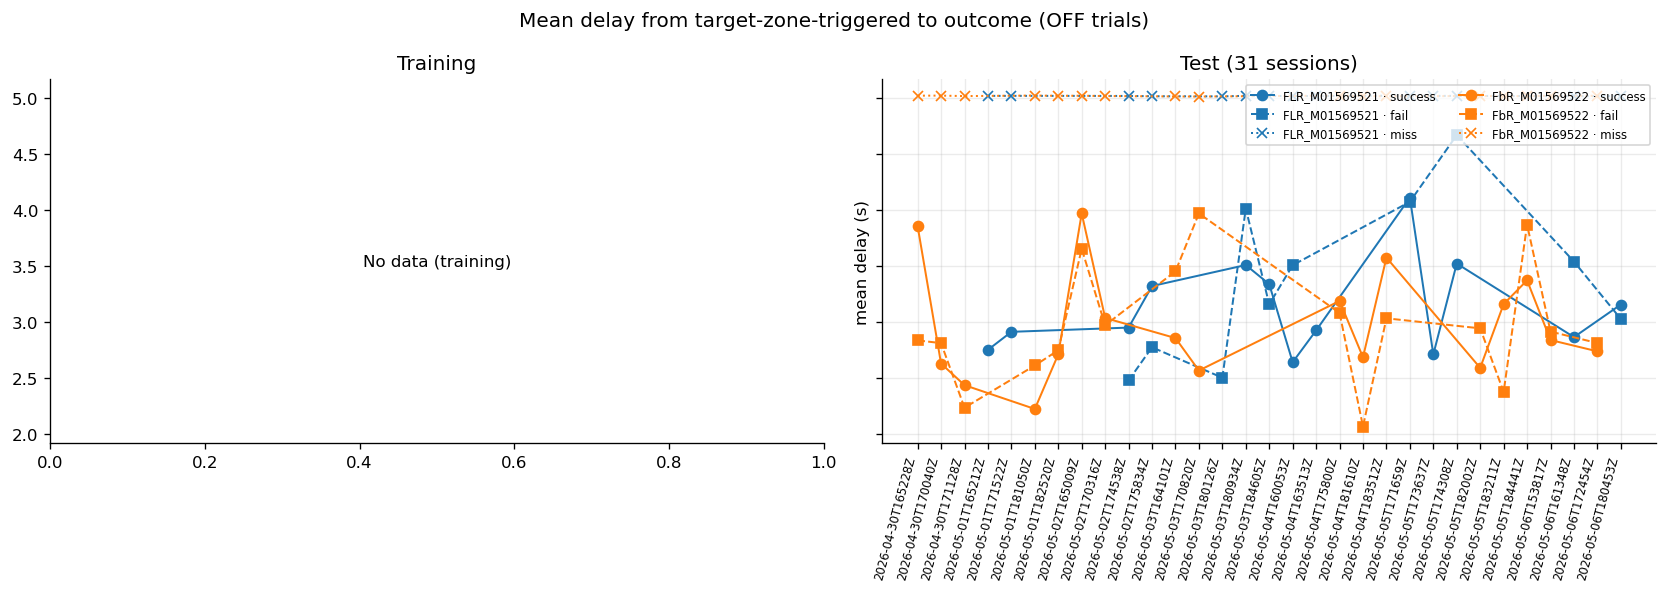

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
delay_per_session = (
    analysis_trials
    .dropna(subset=["inbound_duration"])
    .groupby(["mouse", "session", "USID", "phase", "outcome"], as_index=False)
    .agg(mean_delay=("inbound_duration", "mean"), n=("inbound_duration", "size"))
)


def plot_delay_to_outcome(ax, delay_table, *, phase):
    sub = delay_table.loc[delay_table["phase"] == phase].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data ({phase})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(phase.title())
        return

    session_order = (
        sub[["mouse", "session"]].drop_duplicates().sort_values("session").reset_index(drop=True)
    )
    session_order["x"] = np.arange(len(session_order))
    sub = sub.merge(session_order, on=["mouse", "session"])

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}
    outcome_marker = {"success": "o", "fail": "s", "miss": "x"}
    outcome_ls     = {"success": "-",  "fail": "--", "miss": ":"}

    for mouse, m_sub in sub.groupby("mouse"):
        for oc in ("success", "fail", "miss"):
            o_sub = m_sub[m_sub["outcome"] == oc].sort_values("x")
            if o_sub.empty:
                continue
            ax.plot(
                o_sub["x"], o_sub["mean_delay"],
                color=mouse_colour[mouse],
                marker=outcome_marker.get(oc, "o"),
                linestyle=outcome_ls.get(oc, "-"),
                linewidth=1.2, markersize=6,
                label=f"{mouse} · {oc}",
            )

    ax.set_xticks(session_order["x"])
    ax.set_xticklabels(session_order["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylabel("mean delay (s)")
    ax.set_title(f"{phase.title()} ({len(session_order)} sessions)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, ncol=2, loc="upper right")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_delay_to_outcome(axes[0], delay_per_session, phase="training")
plot_delay_to_outcome(axes[1], delay_per_session, phase="test")
fig.suptitle("Mean delay from target-zone-triggered to outcome (OFF trials)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "05_delay_to_outcome.png", bbox_inches="tight", dpi=300)
plt.show()

display_table(delay_per_session)

## 12. Figure 6 — Delay Between Consecutive Trials

PI summary: *"Delay between 2 trials."* Computed against the **logged** Bonsai start time (`logged_start_time`), not the lab-rule-corrected `start_time` — the lab rule forces `start_time(n+1) = end_time(n) + 1 s` by construction, so plotting that delay would always show exactly 1 s and tell us nothing. The logged delay reflects the actual elapsed wall-clock time between trial-end and the next Bonsai `Start Trial` event.

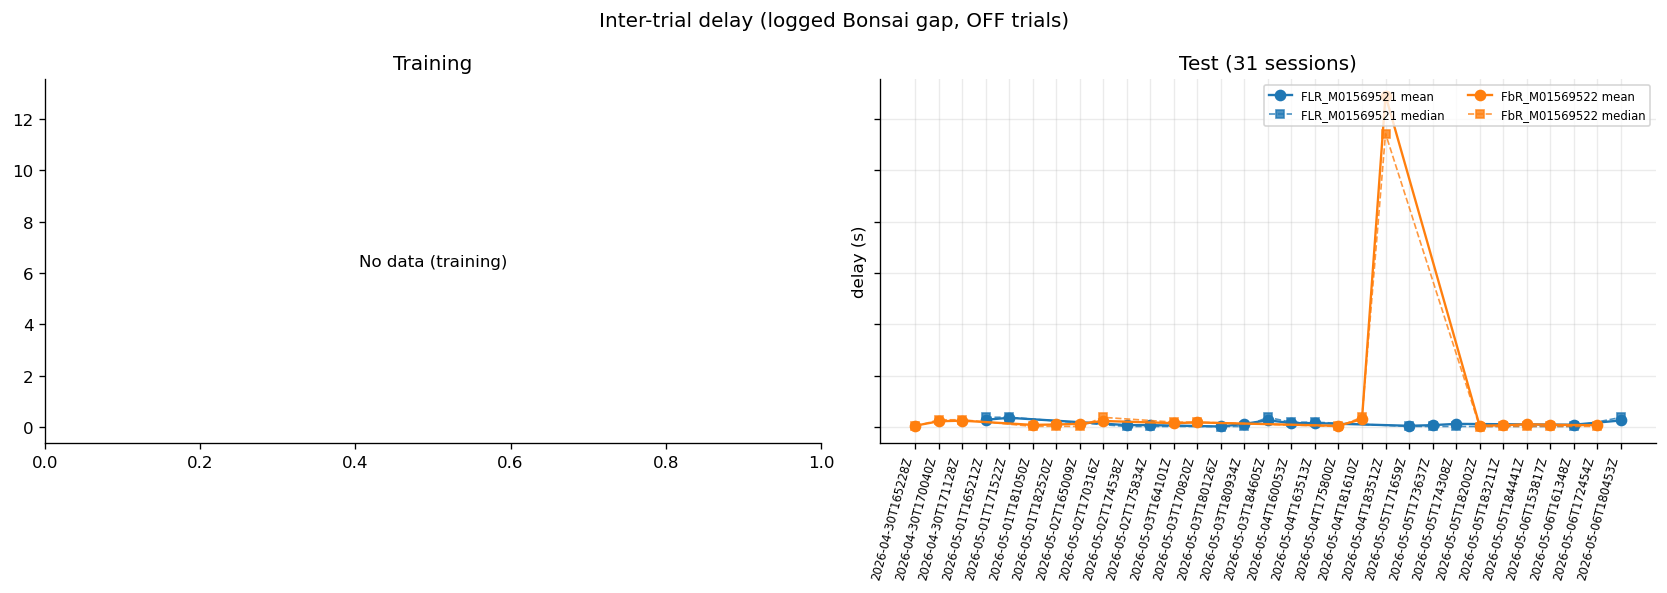

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
analysis_trials = analysis_trials.sort_values(["USID", "off_trial_index"]).copy()
analysis_trials["next_logged_start_time"] = (
    analysis_trials.groupby("USID")["logged_start_time"].shift(-1)
)
analysis_trials["inter_trial_delay"] = (
    analysis_trials["next_logged_start_time"] - analysis_trials["end_time"]
)

inter_trial_per_session = (
    analysis_trials
    .dropna(subset=["inter_trial_delay"])
    .groupby(["mouse", "session", "USID", "phase"], as_index=False)
    .agg(
        mean_delay=("inter_trial_delay", "mean"),
        median_delay=("inter_trial_delay", "median"),
        n=("inter_trial_delay", "size"),
    )
)


def plot_inter_trial(ax, table, *, phase):
    sub = table.loc[table["phase"] == phase].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data ({phase})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(phase.title())
        return

    sub = sub.sort_values("session").reset_index(drop=True)
    sub["x"] = np.arange(len(sub))

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for mouse, m_sub in sub.groupby("mouse"):
        ax.plot(
            m_sub["x"], m_sub["mean_delay"],
            color=mouse_colour[mouse], marker="o", linestyle="-",
            linewidth=1.4, markersize=6, label=f"{mouse} mean",
        )
        ax.plot(
            m_sub["x"], m_sub["median_delay"],
            color=mouse_colour[mouse], marker="s", linestyle="--",
            linewidth=1.0, markersize=5, alpha=0.8, label=f"{mouse} median",
        )

    ax.set_xticks(sub["x"])
    ax.set_xticklabels(sub["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylabel("delay (s)")
    ax.set_title(f"{phase.title()} ({len(sub)} sessions)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, ncol=2, loc="upper right")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_inter_trial(axes[0], inter_trial_per_session, phase="training")
plot_inter_trial(axes[1], inter_trial_per_session, phase="test")
fig.suptitle("Inter-trial delay (logged Bonsai gap, OFF trials)")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "06_inter_trial_delay.png", bbox_inches="tight", dpi=300)
plt.show()

display_table(inter_trial_per_session)

## 13. Figure 7 — Success Rate Over Last 40 / Last 25 OFF Trials

PI summary asks for `Plot success rate for: 1) the last 40 trials; 2) the last 25 trials`. Per session, restrict to the final N OFF trials and compute the success rate over them. Two windows (40 and 25) plotted side-by-side, each panel split by phase. Sessions with fewer than N OFF trials are flagged but still plotted (the rate is computed over whatever is available).

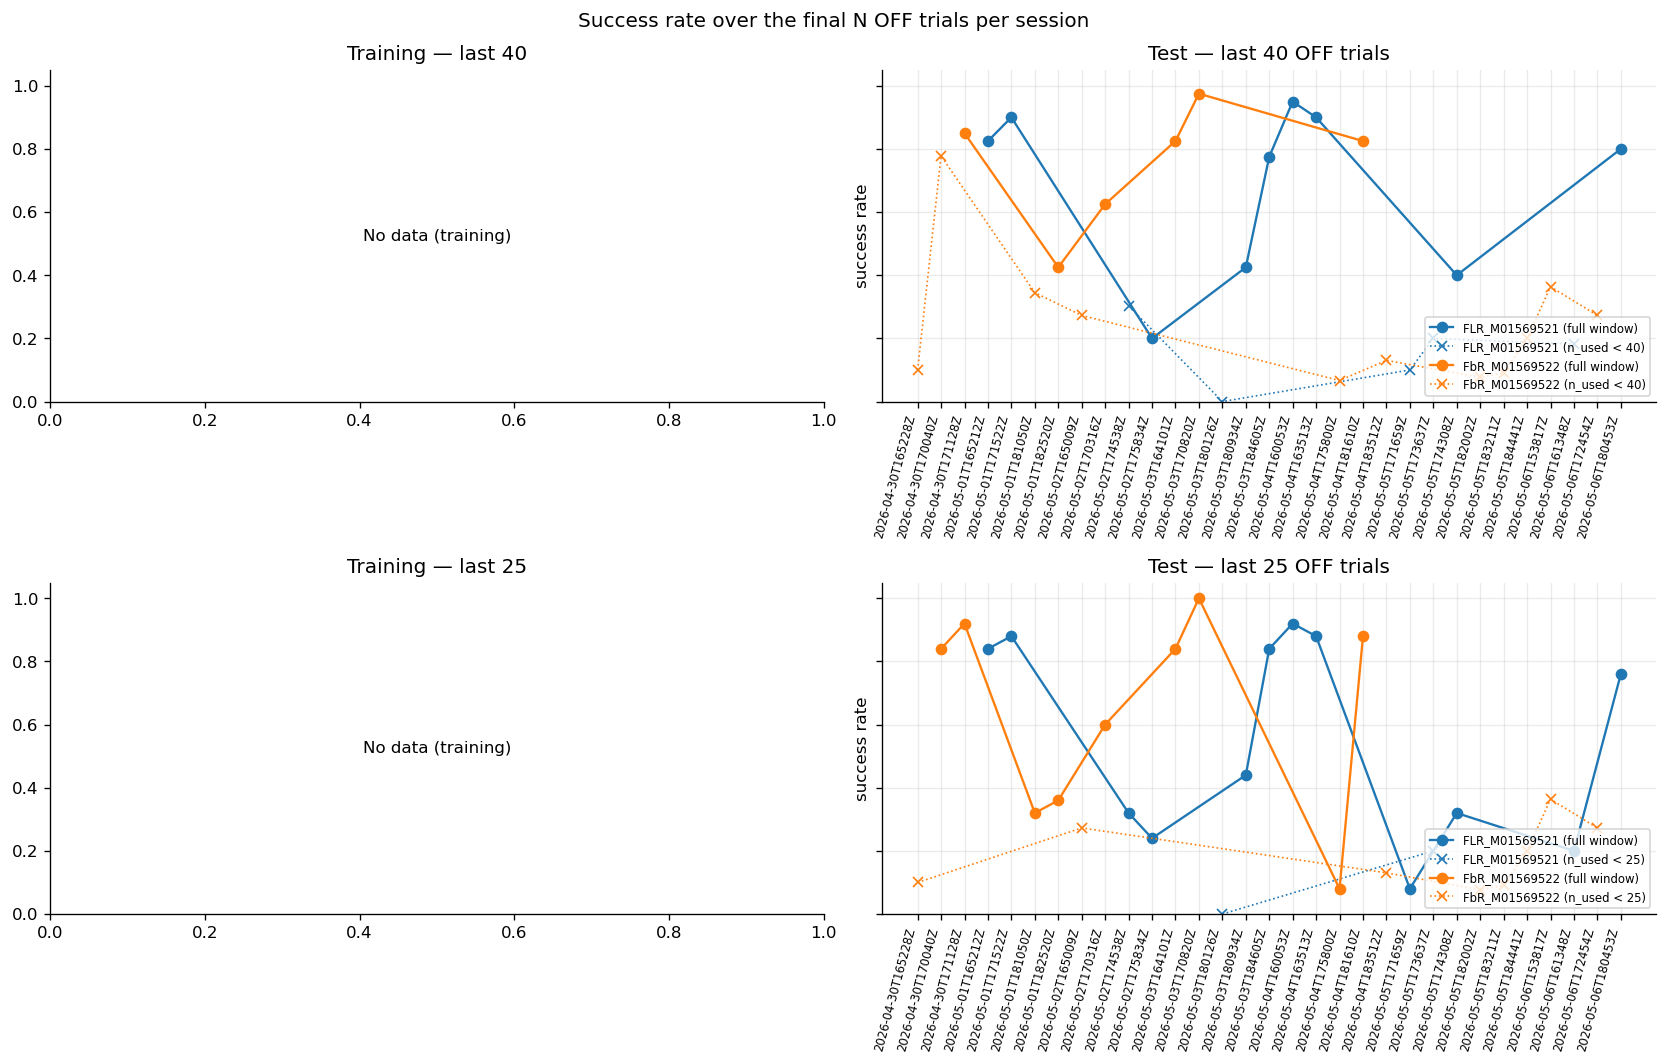

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
def success_rate_last_n(trials, n):
    """Per session, success rate over the final n OFF trials (or fewer if the session is shorter)."""
    rows = []
    for usid, sub in trials.groupby("USID"):
        sub = sub.sort_values("off_trial_index")
        last = sub.tail(n)
        rows.append({
            "USID":   usid,
            "mouse":   sub["mouse"].iloc[0],
            "session": sub["session"].iloc[0],
            "phase":   sub["phase"].iloc[0],
            "window":  n,
            "n_used":  int(len(last)),
            "had_enough": len(sub) >= n,
            "success_rate": float(last["is_success"].mean()) if len(last) else np.nan,
        })
    return pd.DataFrame(rows)


last_n_results = pd.concat(
    [success_rate_last_n(analysis_trials, n) for n in (40, 25)],
    ignore_index=True,
)


def plot_last_n(ax, results, *, window, phase):
    sub = results.loc[(results["window"] == window) & (results["phase"] == phase)].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data ({phase})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{phase.title()} — last {window}")
        return

    sub = sub.sort_values("session").reset_index(drop=True)
    sub["x"] = np.arange(len(sub))

    cmap = plt.get_cmap("tab10")
    mice = sorted(sub["mouse"].unique())
    mouse_colour = {m: cmap(i % 10) for i, m in enumerate(mice)}

    for mouse, m_sub in sub.groupby("mouse"):
        full = m_sub[m_sub["had_enough"]]
        partial = m_sub[~m_sub["had_enough"]]
        if not full.empty:
            ax.plot(
                full["x"], full["success_rate"],
                color=mouse_colour[mouse], marker="o", linewidth=1.4,
                label=f"{mouse} (full window)",
            )
        if not partial.empty:
            ax.plot(
                partial["x"], partial["success_rate"],
                color=mouse_colour[mouse], marker="x", linestyle=":", linewidth=1.0,
                label=f"{mouse} (n_used < {window})",
            )

    ax.set_xticks(sub["x"])
    ax.set_xticklabels(sub["session"], rotation=75, fontsize=7, ha="right")
    ax.set_ylabel("success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{phase.title()} — last {window} OFF trials")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, loc="lower right")


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
plot_last_n(axes[0, 0], last_n_results, window=40, phase="training")
plot_last_n(axes[0, 1], last_n_results, window=40, phase="test")
plot_last_n(axes[1, 0], last_n_results, window=25, phase="training")
plot_last_n(axes[1, 1], last_n_results, window=25, phase="test")
fig.suptitle("Success rate over the final N OFF trials per session")
fig.tight_layout()
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / "07_last_n_success.png", bbox_inches="tight", dpi=300)
plt.show()

display_table(last_n_results)